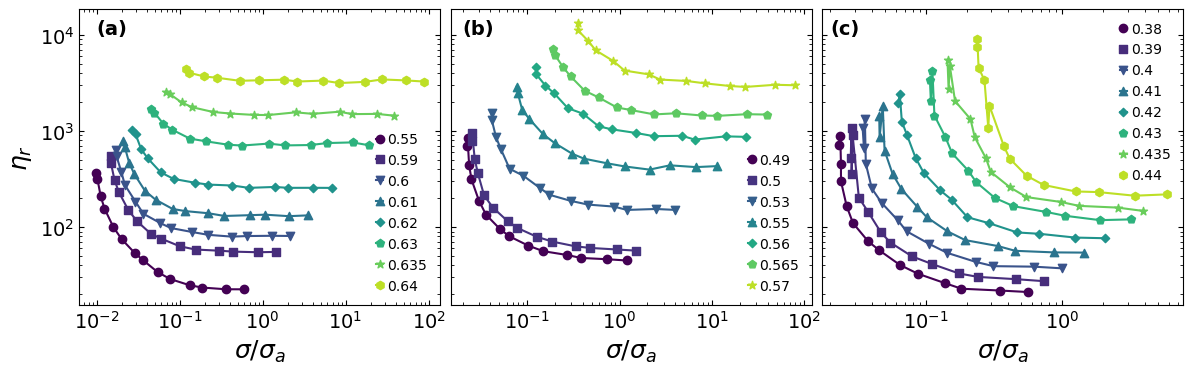

In [3]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

fig_names = ['fig_fc1.pkl', 'fig_fc2.pkl', 'fig_fc3.pkl']
titles = ['Title 1', 'Title 2', 'Title 3']

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=False)

for ax_new, fname, title in zip(axes, fig_names, titles):
    with open(fname, 'rb') as f:
        fig_old = pickle.load(f)
    plt.close(fig_old)

    ax_old = fig_old.axes[0]

    # Associate every _child collection with the most recent named label
    grouped = defaultdict(lambda: {'x': [], 'y': [], 'marker': None})#
    current_label = None

    for col in ax_old.collections:
        label = col.get_label()
        if not label.startswith('_'):
            current_label = label  # new named series
        if current_label is None:
            continue
        offsets = col.get_offsets()
        if len(offsets) == 0:
            continue
        grouped[current_label]['x'].append(offsets[0, 0])
        grouped[current_label]['y'].append(offsets[0, 1])
        if grouped[current_label]['marker'] is None:
            grouped[current_label]['marker'] = col.get_paths()[0]

    colours = plt.cm.viridis(np.linspace(0, 0.9, len(grouped)))

    for (label, data), colour in zip(grouped.items(), colours):
        xdata = np.array(data['x'])
        ydata = np.array(data['y'])
        order = np.argsort(xdata)
        ax_new.plot(xdata[order], ydata[order],
            color=colour,
            marker=data['marker'],
            linestyle='-',
            label=label)

    ax_new.set_xscale('log')
    ax_new.set_yscale('log')
    ax_new.set_xlabel('$\\sigma / \\sigma_a$', fontsize=18, fontweight='bold')
    ax_new.minorticks_on()
    ax_new.tick_params(axis='both', which='both', direction='in',
                       top=True, right=True, labelsize=14)
    ax_new.legend(fontsize=10, frameon=False, handlelength=0.5, handletextpad=0.3)

axes[0].set_ylabel('$\\eta_r$', fontsize=18, fontweight='bold')
axes[0].tick_params(axis='y', labelleft=True, labelsize=14)
axes[0].text(1e-2, 1e4, '(a)', fontsize=14, fontweight='bold')
axes[1].text(20e-3, 1e4, '(b)', fontsize=14, fontweight='bold')
axes[2].text(20e-3, 1e4, '(c)', fontsize=14, fontweight='bold')

for ax in axes[1:]:
    ax.tick_params(axis='y', labelleft=False)

fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.18, wspace=0.03)
plt.savefig('viscosity_joint.png', dpi=1200)
plt.show()